In [2]:
from rdkit import Chem
from pathlib import Path 
import rdkit

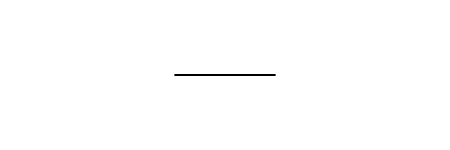

In [3]:
smile='CC'
#smile = '[B-]1(n2cccc2C=C3[N+]1=CC=C3)(F)F'
smi_key='BODIPY'
mol_rdkit = Chem.MolFromSmiles(smile)
mol_rdkit

In [4]:
import py3Dmol 

In [5]:
 # Verify if the "data2408_{smi_key}" subdirectory exist and if not, create it
working_dir = Path(f'./data2408/{smi_key}')
# Create the output directory if it doesn't exist
working_dir.mkdir(parents=True, exist_ok=True)


In [6]:

def view3D(mol, label, fmt='mol'):
        """3D vizualisation of mol/xyz file with Py3DMol
        """

        view = py3Dmol.view(width=400, height=400)       # visualiser la molécule avec une largeur de ''400'' et hauteur de ''400''

        if fmt=='mol':                                   # si le format des 'mol',
            view.addModel(Chem.MolToMolBlock(mol), fmt)     # generer les coordonnes de a molecule dans un block
            # view.addModel(mol, fmt)
        elif fmt=='xyz':                                      # sinon 
            view.addModel(mol, fmt)                             # generer les coordonnes en xyz

        view.setStyle({'stick': {}, 'sphere': {'scale': .30}})     # définir le style de représentation de la molécule, avec des bâtons pour les liaisons et des sphères pour les atomes avec une échelle de '30'
        view.addLabel(label, {'position': {'x': -2, 'y': -3, 'z': 0}}) # ajouter une etiquette de visualisation dont les coordonnées sont x,y,z

        view.zoomTo()
        view.show()

### Meilleure conformation

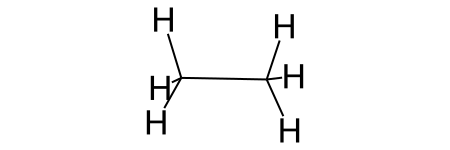

In [7]:
from rdkit.Chem import AllChem

# Add explicit Hs
mol_rdkit = Chem.AddHs(mol_rdkit)    #   Ajouter les atomes d'hydrogene a la molécule

# Generates the initial 3D conformation of the molecule
AllChem.EmbedMolecule(mol_rdkit)
mol_rdkit

### Visualisation 3D

In [8]:
# 3D visualization
mol_rdkit0 = mol_rdkit                    #crée une nouvelle variable mol_rdkit0 qui est une copie de mol_rdkit.
                                           #Cette copie est nécessaire pour la visualisation 3D, car la fonction view3D() modifie l'objet molécule passé en argument.

view3D(mol_rdkit0, f'{smi_key} RDKit Molecule')


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [9]:
# Convert RDKit molecule to XYZ format 
mol_xyz0 = Chem.MolToXYZBlock(mol_rdkit)    # Convertir  la molecule format XYZ 
# print(mol_xyz0)

### Préoptimisation avec RDKIT 
#### Visualisation 3D

In [10]:
from rdkit.Chem import AllChem

# Optimizes the 3D conformation of the molecule using MMFF - Merck Molecular Force Field
AllChem.MMFFOptimizeMolecule(mol_rdkit, maxIters=200, mmffVariant="MMFF94s")   # utiliser 200 itérations et la variante MMFF94s

#Canonicalize the orientation of the conformation
Chem.rdMolTransforms.CanonicalizeMol(mol_rdkit, normalizeCovar=True, ignoreHs=False)

# 3D visualization
mol_rdkit1 = mol_rdkit
view3D(mol_rdkit1, f'{smi_key} RDKit Molecule MMFF94')


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [11]:
# Setting various paths for files
path_xtb_xyz = working_dir / f'{smi_key}_opt.xyz'
path_xtb_log = working_dir / f'{smi_key}_opt.log'
path_rdkit_xyz = working_dir / f'{smi_key}_rdkit.xyz'

# Convert RDKit molecule to XYZ format 
mol_xyz = Chem.MolToXYZBlock(mol_rdkit)    # Convertir  la molecule format XYZ 
with open("mol_rdkit.xyz", "w") as f:
    f.write(mol_xyz)

### Optimisation avec xTB et CREST

In [12]:
%%bash
# Best conformation search with CREST 3 which integrate pre-optimization with xTB 
crest mol_rdkit.xyz --gfn2 --mquick --prop hess --noreftopo -T 4 --alpb Toluene

# xTB geometry optimization of the crest best conformation
xtb crest_best.xyz --gfn 2 --ohess vtight --parallel 4 --alpb Toluene > xtb.out

 
       ╔════════════════════════════════════════════╗
       ║            ___ ___ ___ ___ _____           ║
       ║           / __| _ \ __/ __|_   _|          ║
       ║          | (__|   / _|\__ \ | |            ║
       ║           \___|_|_\___|___/ |_|            ║
       ║                                            ║
       ║  Conformer-Rotamer Ensemble Sampling Tool  ║
       ║          based on the xTB methods          ║
       ║                                            ║
       ╚════════════════════════════════════════════╝
       Version 3.0.1, Mon May  6 18:43:33 UTC 2024
       commit (1782d7d) compiled by 'runner@fv-az772-53'
 
   Cite work conducted with this code as

   • P.Pracht, F.Bohle, S.Grimme, PCCP, 2020, 22, 7169-7192.
   • S.Grimme, JCTC, 2019, 15, 2847-2862.
   • P.Pracht, S.Grimme, C.Bannwarth, F.Bohle, S.Ehlert,
     G.Feldmann, J.Gorges, M.Müller, T.Neudecker, C.Plett,
     S.Spicher, P.Steinbach, P.Wesołowski, F.Zeller,
     J. Chem. Phys., 2024, 160, 11

 Trial MTD 1 runtime (1.0 ps) ...        0 min,  0.632 sec
 Estimated runtime for one MTD (2.5 ps) on a single thread: 2 sec
 Estimated runtime for a batch of 6 MTDs on 4 threads: 3 sec
 
******************************************************************************************
**                         N E W   I T E R A T I O N  C Y C L E                         **
******************************************************************************************
 
 ------------------------------
 Meta-Dynamics Iteration 1
 ------------------------------
 list of applied metadynamics Vbias parameters:
$metadyn    0.01600   1.000
$metadyn    0.00800   1.000
$metadyn    0.01600   0.500
$metadyn    0.00800   0.500
$metadyn    0.01600   0.250
$metadyn    0.00800   0.250
 
  ::::::::::::: starting MTD    3 :::::::::::::
  |   MD simulation time   :     2.5 ps       |
  |   target T             :   300.0 K        |
  |   timestep dt          :     5.0 fs       |
  |   dump interval(trj)   :   100.0

normal termination of xtb
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DENORMAL


In [13]:
import subprocess as sp

# Store various files 
sp.run(['cp', 'xtbopt.xyz', path_xtb_xyz], stdout=sp.DEVNULL, stderr=sp.DEVNULL)
sp.run(['mv', 'xtb.out', path_xtb_log], stdout=sp.DEVNULL, stderr=sp.DEVNULL)
sp.run(['mv', 'mol_rdkit.xyz', path_rdkit_xyz], stdout=sp.DEVNULL, stderr=sp.DEVNULL)

# Deleted various TB files before the next optimization calculations
sp.run(['rm', 'bondlengths', 'charges', 'coord', 'coord.original', 'cregen_0.tmp','spec.dat','rots.dat',
                'cregen_1.tmp', 'cre_members', 'crest_conformers.xyz', 'vibspectrum', 'hessian', 'g98.out',
                'crest.energies', 'crest_rotamers.xyz', 'gfnff_charges', 'gfnff_topo', 'wfn.xtb', 'xtbhess.xyz',
                '.history.xyz', 'struc.xyz', 'wbo', 'xtbopt.xyz', 'xtbopt.log', '.xtboptok', 'crest_property.xyz',
                'xtbrestart', 'xtbtopo.mol', 'xtblast.xyz', 'gfnff_adjacency', 
                'ensemble_energies.log', 'charges3', 'charges', 'molden.input', 'crest_0.mdrestart',
                'crest_dynamics.trj', 'crestopt.log', 'crest.restart', 'crest_input_copy.xyz'], stdout=sp.DEVNULL, stderr=sp.DEVNULL)
        # For folder
sp.run(['rm', '-r', 'calculation.level.1', 'PROP'], stdout=sp.DEVNULL, stderr=sp.DEVNULL)



CompletedProcess(args=['rm', '-r', 'calculation.level.1', 'PROP'], returncode=0)

In [14]:
# Calculate the RMSD to evaluate the optimally (minimum RMSD) alignment of mol_rdkit1  with mol_xtb
mol1 = Chem.MolFromXYZFile(f'{path_rdkit_xyz}')
mol2 = Chem.MolFromXYZFile(f'{path_xtb_xyz}')
AllChem.AlignMol(mol1, mol2)

0.8845907978054802

In [15]:
# Calculate the RMSD to evaluate the optimally (minimum RMSD) alignment of mol_rdkit1  with mol_xtb
mol22 = Chem.MolFromXYZFile(f'BODIPY_Opt_DFT.xyz')
AllChem.AlignMol(mol2, mol22)

1.2473387226286539

### Creation de l'objet mole

In [16]:
from tangelo import SecondQuantizedMolecule as SQMol
from tangelo.helpers.utils import is_package_installed

# Remove the first two lines (number of atoms and empty line) from XYZ data
# mol_xyz1 = '\n'.join(path_xtb_xyz.read_text().strip().split('\n')[2:]) 
mol_xyz1 = '\n'.join(open('BODIPY_Opt_DFT.xyz').read().strip().split('\n')[2:]) 


BODIPY_631g = SQMol(mol_xyz1, q=0, spin=0, basis="6-31g", symmetry=True)
print(f"In the {BODIPY_631g.basis} basis the number of ")
print(f"active molecular orbitals = {BODIPY_631g.n_active_mos} ")
print(f"active electrons = {BODIPY_631g.n_active_electrons} ")

In the 6-31g basis the number of 
active molecular orbitals = 28 
active electrons = 14 


The full calculation of BODIPY in the `6-31G` basis would entail 70 electrons in 126 orbitals, with the core electrons frozen. The number of qubits needed to represent this would be 126*2=252 for the Jordan-Wigner mapping. [J. Chem. Theory. Comput. 2015, 11, 6](https://pubs.acs.org/doi/10.1021/ct500775r) showed reasonable results using CASSCF with 12 electrons in 11 orbitals, which would be a 22-qubit problem using the Jordan-Wigner mapping. Another issue is the number of CNOT gates, which would be much larger for the full 22-qubit problem than shown in the table for our use case. 

This system is orders or magnitude harder, and emphasize how it is crucial that we design and choose approaches that require as little quantum computational resources as possible to make such use cases tractable in the future.

There is still much work to be done to efficiently calculate excited states using quantum computers, and allow us to tackle more industrially-relevant use cases.

What will you do with Tangelo? 

In [17]:
import plotly.express as px

# Plot the MO Occupations
fig = px.line(y=BODIPY_631g.mo_occ, markers=True, title="Molecular Orbital (MO) Occupations")
fig.update_layout(xaxis_title="Orbital Index (0-Based)", yaxis_title="MO Occupation")
fig.show()

In [18]:
# Plot the MO Energies (i.e. eigenvalues of the Fock matrix)
fig = px.line(y=BODIPY_631g.mo_energies, markers=True, title="Molecular Orbital (MO) Energies (a.u.)")
fig.update_layout(xaxis_title="Orbital Index (0-Based)", yaxis_title="MO Energies (a.u.)")
fig.show()

In [19]:
n_lumo = BODIPY_631g.mo_occ.tolist().index(0.)
n_homo = n_lumo - 1
print(f"homo index: {n_homo} ")
print(f"lumo index: {n_lumo} ")

print(f'Number of molecular orbitals :{BODIPY_631g.n_mos}')
print(f"Number of spin-orbitals = {BODIPY_631g.n_sos} ")

homo index: 8 
lumo index: 9 
Number of molecular orbitals :30
Number of spin-orbitals = 60 


### Mean-field calculations

In [20]:
import dftd4.pyscf as disp
from pyscf import solvent

mf = BODIPY_631g.mean_field

# Utiliser la méthode "ddCOSMO" de l'objet "solvent"
mf = mf.run().ddCOSMO()
mf.with_solvent.eps = 2.3741   # Toluene
mfd = disp.energy(mf).run()


In [21]:
mfd.dump_scf_summary()

**** SCF Summaries ****
Total Energy =                         -79.209341038672491
Nuclear Repulsion Energy =              42.414068147922734
One-electron Energy =                 -189.319523603109815
Two-electron Energy =                   67.696199548740822
Empirical Dispersion Energy =           -0.011928224934933


In [22]:
mf.to_rks
mf.xc='B3LYP' # la fonctionnelle
mfd = disp.energy(mf).run()

# mf.kernel()
mfd.dump_scf_summary()

**** SCF Summaries ****
Total Energy =                         -79.201711793638481
Nuclear Repulsion Energy =              42.421697392956865
One-electron Energy =                 -189.319523603109985
Two-electron Energy =                   67.696199548740864
Empirical Dispersion Energy =           -0.004298979900804


### Active space definition

In [23]:
from tangelo.toolboxes.molecular_computation.frozen_orbitals import get_orbitals_excluding_homo_lumo

# Selecting HOMO-0 to LUMO+0 orbitals.
frozen = get_orbitals_excluding_homo_lumo(BODIPY_631g, homo_minus_n=0, lumo_plus_n=0)

BODIPY_631g_frozen = SQMol(mol_xyz1, q=0, spin=0,
                                            basis="6-31g",
                                            frozen_orbitals=frozen, symmetry=True)
BODIPY_631g_frozen_t = SQMol(mol_xyz1, q=0, spin=2,
                                            basis="6-31g",
                                            frozen_orbitals=frozen, symmetry=True)


n_as_MO = BODIPY_631g_frozen.n_active_mos
n_as_el = BODIPY_631g_frozen.n_active_electrons
as_orbitals = BODIPY_631g_frozen.active_mos
print(f"{as_orbitals} is the active space")
print(f"{n_as_MO} active molecular orbitals")
print(f"{n_as_el} active electrons")


[8, 9] is the active space
2 active molecular orbitals
2 active electrons


In [24]:
from pyscf.tools import cubegen
from tangelo.toolboxes.molecular_computation.integral_solver_pyscf import mol_to_pyscf

mol_pyscf = mol_to_pyscf(BODIPY_631g_frozen, 
                         BODIPY_631g_frozen.basis, 
                         BODIPY_631g_frozen.symmetry)

# Output cube files for active orbitals that can read by Jmol. Avogadro, Gabedit
for i in BODIPY_631g_frozen.active_mos:
    cubegen.orbital(
        mol_pyscf, 
        f'BODIPY_{i+1}.cube', 
        BODIPY_631g_frozen.mean_field.mo_coeff[:, i])

### FCI Solver calculation

 The `FCISolver` class ( Full CI method) can be used to produce a classically-computed reference value.

In [26]:
from tangelo.algorithms.classical import FCISolver
import time

n_states = 2 # GS + 1 ES (S0, S1)
# Measure execution time.
for i in range(0,n_states):
    start = time.time()
    e_FCI = FCISolver(BODIPY_631g_frozen).simulate()
    end = time.time()
    time_FCI = end-start
    print(f"Energie of state S{i}: {e_FCI} Hartree (Temps d'exécution : {time_FCI} secondes)")

start_t = time.time()
e_FCI_t = FCISolver(BODIPY_631g_frozen_t).simulate()
end_t = time.time()
time_FCI_t = end_t-start_t

print(f"FCI T1 energy = {e_FCI_t}")
print(f"Execution time FCI_t = {time_FCI_t}")

Energie of state S0: -79.19741777224945 Hartree (Temps d'exécution : 0.006435394287109375 secondes)
Energie of state S1: -79.19741777224947 Hartree (Temps d'exécution : 0.011866092681884766 secondes)
FCI T1 energy = -78.74958985140296
Execution time FCI_t = 0.011669158935546875


### CASSCF and CASCI excited state energies

#### Singlet calculations

In [25]:
from pyscf import mcscf
import numpy as np

# Conversion of Hartree to kcal per mol
au2kcal = 627.509474

n_states = 3 # GS + 2 ES (S0, S1, S2)
mycas = mcscf.CASSCF(BODIPY_631g.mean_field, 
                  n_as_MO,
                  n_as_el).state_average([1.0/n_states]*n_states)

mycas = solvent.ddCOSMO(mycas)
# Adjust solvent model by modifying the attribute .with_solvent
mycas.with_solvent.eps = 2.3741  # Toluene dielectric constant

print("CASSCF Calculations \n")

# Measure time execution for theses energies
start_casscf = time.time()
mycas.kernel()
end_casscf = time.time()
casscf_time = end_casscf - start_casscf
print(f"Temps d'exécution des énergies CASSCF: {casscf_time} secondes")

print("\n------------------------------------------------")

for i in range(0, n_states):
    
    start_time = time.time()
    energy = mycas.e_states[i]
    end_time = time.time()
    state_time = end_time - start_time
    print(f"Energie of state S{i}: {energy} Hartree (Temps d'exécution : {state_time} secondes)")

print("\n-----Difference from FCI in kcal------------------------")
np.abs(mycas.e_states[0] - e_FCI) * au2kcal


CASSCF Calculations 

CASSCF energy = -78.8901952255651
CASCI E = -78.8901952255651  E(CI) = -1.02254657975489  S^2 = 0.6666667
CASCI state-averaged energy = -78.8525964252594
CASCI energy for each state
  State 0 weight 0.333333  E = -79.1543125467407 S^2 = 0.0000000
  State 1 weight 0.333333  E = -78.7133070204207 S^2 = 2.0000000
  State 2 weight 0.333333  E = -78.6901697086169 S^2 = 0.0000000
Temps d'exécution des énergies CASSCF: 18.099012851715088 secondes

------------------------------------------------
Energie of state S0: -79.15431254674068 Hartree (Temps d'exécution : 7.3909759521484375e-06 secondes)
Energie of state S1: -78.71330702042074 Hartree (Temps d'exécution : 2.6226043701171875e-06 secondes)
Energie of state S2: -78.6901697086169 Hartree (Temps d'exécution : 1.9073486328125e-06 secondes)

-----Difference from FCI in kcal------------------------


27.04893738556019

In [26]:

n_states = 3 # GS + 2 ES (S0, S1, S2)
mycas2 = mcscf.CASSCF(mf, 
                  n_as_MO,
                  n_as_el).state_average([1.0/n_states]*n_states)

mycas2 = solvent.ddCOSMO(mycas2)
# Adjust solvent model by modifying the attribute .with_solvent
mycas2.with_solvent.eps = 2.3741  # Toluene dielectric constant

print("CASSCF Calculations with KS\n")

# Mesurer le temps d'exécution pour le calcul CASSCF
start_time = time.time()
mycas2.kernel()
casscf_time = time.time() - start_time
print(f"Temps d'exécution du calcul CASSCF: {casscf_time} secondes")

print("\n------------------------------------------------")

state_times = []
for i in range(0, n_states):
    # Mesurer le temps d'exécution pour chaque état
    start_time = time.time()
    energy = mycas2.e_states[i]
    state_time = time.time() - start_time
    state_times.append(state_time)
    print(f"Energie of state S{i}: {energy} Hartree (Temps d'exécution: {state_time} secondes)")

print("\n-----Difference from FCI in kcal------------------------")
np.abs(mycas2.e_states[0] - e_FCI) * au2kcal




CASSCF Calculations with KS

CASSCF energy = -78.8901952251732
CASCI E = -78.8901952251732  E(CI) = -1.02254648475086  S^2 = 0.6666667
CASCI state-averaged energy = -78.852596445939
CASCI energy for each state
  State 0 weight 0.333333  E = -79.1543125520094 S^2 = 0.0000000
  State 1 weight 0.333333  E = -78.7133070486619 S^2 = 2.0000000
  State 2 weight 0.333333  E = -78.6901697371455 S^2 = 0.0000000
Temps d'exécution du calcul CASSCF: 19.371373653411865 secondes

------------------------------------------------
Energie of state S0: -79.15431255200944 Hartree (Temps d'exécution: 5.7220458984375e-06 secondes)
Energie of state S1: -78.71330704866193 Hartree (Temps d'exécution: 3.337860107421875e-06 secondes)
Energie of state S2: -78.69016973714552 Hartree (Temps d'exécution: 9.5367431640625e-07 secondes)

-----Difference from FCI in kcal------------------------


27.048934079363594

In [28]:
myci = mcscf.CASCI(mf, n_as_MO, n_as_el)
myci = solvent.ddCOSMO(myci)
# Adjust solvent model by modifying the attribute .with_solvent
myci.with_solvent.eps = 2.3741  # Toluene dielectric constant
myci.fcisolver.wfnsym = 1
myci.fcisolver.nroots = 3 # S0, S1, S2

print("CASCI Calculations with KS")

# Mesurer le temps d'exécution pour le calcul CASCI
start_time = time.time() 
myci.kernel()
casci_time = time.time() - start_time
print(f"Temps d'exécution du calcul CASCI: {casci_time} secondes")

print("\n------------------------------------------------")

state_times = []
for i in range(0, n_states):
    # Mesurer le temps d'exécution pour chaque état
    start_time = time.time()
    energy = myci.e_tot[i]
    state_time = time.time() - start_time
    state_times.append(state_time)
    print(f"Energie of state S{i}: {energy} Hartree (Temps d'exécution: {state_time} secondes)")

print("\n-----Difference from FCI in kcal------------------------")
np.abs(mycas.e_states[0] - e_FCI) * au2kcal

CASCI Calculations with KS
CASCI state   0  E = -79.1855346195699  E(CI) = -1.34487620312130  S^2 = 0.0000000
CASCI state   1  E = -78.7240656837992  E(CI) = -0.883407267350563  S^2 = 2.0000000
CASCI state   2  E = -78.7049934260463  E(CI) = -0.864335009597681  S^2 = 0.0000000


CASCI state   0  E = -79.1855346195695  E(CI) = -1.34487620312139  S^2 = 0.0000000
CASCI state   1  E = -78.7240656837987  E(CI) = -0.883407267350577  S^2 = 2.0000000
CASCI state   2  E = -78.7049934260458  E(CI) = -0.864335009597710  S^2 = 0.0000000

WARN: Mulitple states found in CASCI solver. First state is used to compute the Fock matrix and natural orbitals in active space.

Total energy with solvent effects
CASCI state   0  E = -79.1975011919892  E(CI) = -1.34487620312139  S^2 = 0.0000000
CASCI state   1  E = -78.7360322562184  E(CI) = -0.883407267350591  S^2 = 2.0000000
CASCI state   2  E = -78.7169599984655  E(CI) = -0.864335009597724  S^2 = 0.0000000
Temps d'exécution du calcul CASCI: 2.5858538150787354 secondes

------------------------------------------------
Energie of state S0: -79.19750119198919 Hartree (Temps d'exécution: 3.337860107421875e-06 secondes)
Energie of state S1: -78.7360322562184 Hartree (Temps d'exécution: 7.152557373046875e-07 secondes)
Energie of state S2:

27.04893738556019

#### Triplet calculations

In [30]:
n_states = 3 # GS + 2 ES (S0, S1, S2)
mycas_t = mcscf.CASSCF(mf, 
                  n_as_MO,
                  n_as_el).state_average([1.0/n_states]*n_states)

mycas_t.fcisolver.wfnsym = "3"
mycas_t = solvent.ddCOSMO(mycas_t)
# Adjust solvent model by modifying the attribute .with_solvent
mycas_t.with_solvent.eps = 2.3741  # Toluene dielectric constant

print("CASSCF Calculations\n")

# Mesurer le temps d'exécution pour le calcul CASSCF des états triplets
start_time = time.time()
mycas_t.kernel()
casscf_triplet_time = time.time() - start_time
print(f"Temps d'exécution du calcul CASSCF des états triplets: {casscf_triplet_time} secondes")


print("\n------------------------------------------------")

state_times = []
for i in range(0, n_states):
    start_time = time.time()
    energy = mycas_t.e_states[i]
    state_time = time.time() - start_time
    state_times.append(state_time)
    print(f"Energie of state T{i}: {energy} Hartree (Temps d'exécution: {state_time} secondes)")

print("\n-----Difference from FCI in kcal------------------------")
np.abs(mycas_t.e_states[0] - e_FCI_t) * au2kcal

CASSCF Calculations

CASSCF energy = -78.8901950309492
CASCI E = -78.8901950309492  E(CI) = -1.02253240758378  S^2 = 0.6666667
CASCI state-averaged energy = -78.852595291604
CASCI energy for each state
  State 0 weight 0.333333  E = -79.1543127861832 S^2 = 0.0000000
  State 1 weight 0.333333  E = -78.7133049849067 S^2 = 2.0000000
  State 2 weight 0.333333  E = -78.6901681037222 S^2 = 0.0000000
Temps d'exécution du calcul CASSCF des états triplets: 25.18390941619873 secondes

------------------------------------------------
Energie of state T0: -79.15431278618321 Hartree (Temps d'exécution: 1.3589859008789062e-05 secondes)
Energie of state T1: -78.71330498490673 Hartree (Temps d'exécution: 1.1920928955078125e-06 secondes)
Energie of state T2: -78.69016810372223 Hartree (Temps d'exécution: 7.62939453125e-06 secondes)

-----Difference from FCI in kcal------------------------


253.9674759198889

<!-- ### Hamiltonien -->

#### Oscillator strength calculations

In [31]:
try:
    import veloxchem as vlx
except:
    !conda install veloxchem multipsi -c veloxchem
    
import multipsi as mtp

In [32]:
mol_str = open('BODIPY_Opt_DFT.xyz').read()
molecule = vlx.Molecule.read_xyz_string(mol_str)
basis = vlx.MolecularBasis.read(molecule, "6-31g")

scf_drv = vlx.ScfRestrictedDriver()
scf_results = scf_drv.compute(molecule, basis)

* Info * Reading basis set from file: /home/fortune/anaconda3/lib/python3.11/site-packages/veloxchem/basis/6-31G          
                                                                                                                          
                                              Molecular Basis (Atomic Basis)                                              
                                                                                                                          
                               Basis: 6-31G                                                                               
                                                                                                                          
                               Atom Contracted GTOs           Primitive GTOs                                              
                                                                                                                          
                

* Info * Starting Reduced Basis SCF calculation...                                                                        
* Info * ...done. SCF energy in reduced basis set: -79.197328491240 a.u. Time: 0.67 sec.                                  
                                                                                                                          
* Info * Overlap matrix computed in 0.00 sec.                                                                             
                                                                                                                          
* Info * Kinetic energy matrix computed in 0.00 sec.                                                                      
                                                                                                                          
* Info * Nuclear potential matrix computed in 0.00 sec.                                                                   
                

In [33]:
# CAS calculation 
space=mtp.OrbSpace(molecule,scf_drv.mol_orbs)
space.cas(2,2) 

# CASSCF GS Calculations
mcscf_drv=mtp.McscfDriver()
mcscf_results = mcscf_drv.compute(molecule,basis,space)

                                                                                                                          
                          Multi-Configurational Self-Consistent Field Driver
                                                                                                                          
        ╭────────────────────────────────────╮
        │          Driver settings           │
        ╰────────────────────────────────────╯
          State-specific calculation
          Max. iterations         : 50
          BFGS window             : 5
          Convergence thresholds:
            - Energy change       : 1e-08
            - Gradient norm       : 0.0001
                                                                                                                          
          Integrals in memory
                                                                                                                          

          Active space def

        4     -79.201095357    -1.7e-03      4.4e-03          1   0:00:00
        5     -79.201185925    -9.1e-05      2.2e-03          1   0:00:00
        6     -79.201238603    -5.3e-05      8.2e-04          1   0:00:00
        7     -79.201241767    -3.2e-06      3.8e-04          1   0:00:00
        8     -79.201243769    -2.0e-06      3.6e-04          1   0:00:00
        9     -79.201311458    -6.8e-05      5.6e-03          1   0:00:00
       10     -79.202347661    -1.0e-03      7.8e-03          1   0:00:00
       11     -79.207227508    -4.9e-03      1.7e-02          1   0:00:00
       12     -79.212649381    -5.4e-03      1.3e-02          1   0:00:00
       13     -79.212191934     4.6e-04      1.2e-02          1   0:00:00
       14     -79.213211503    -1.0e-03      3.1e-03          1   0:00:00
       15     -79.213222814    -1.1e-05      1.6e-03          1   0:00:00
       16     -79.213227531    -4.7e-06      6.9e-04          1   0:00:00
       17     -79.213227655    -1.2e-0

In [34]:
# CASSCF excitation energies
nstates=3
mcscf_results = mcscf_drv.compute(molecule,basis,space,nstates)

# Transition properties
SI=mtp.InterState()
DipOsc=SI.compute(molecule, basis, mcscf_results)

                                                                                                                          
                          Multi-Configurational Self-Consistent Field Driver
                                                                                                                          
        ╭────────────────────────────────────╮
        │          Driver settings           │
        ╰────────────────────────────────────╯
          State-averaged calculation
            Number of states      : 3
            Equal-weights 
          Max. iterations         : 50
          BFGS window             : 5
          Convergence thresholds:
            - Energy change       : 1e-08
            - Gradient norm       : 0.0001
                                                                                                                          
          Integrals in memory
                                                                                     

In [35]:
au2ev = 27.211386

print("------CASSCF Calculations--------")
print(f"Energies : {au2ev*DipOsc['energies']}eV")
print(f"Oscillator strengths : {DipOsc['oscillator_strengths']}")

------CASSCF Calculations--------
Energies : [12.62825208 26.46848337]eV
Oscillator strengths : [2.50596594e-07 2.81126741e-10]


In [36]:
# CASCI excitation energies
cidrv=mtp.CIDriver()
ci_results = cidrv.compute(molecule,basis,space,nstates)

# Transition properties
DipOsc2=SI.compute(molecule, basis, ci_results)

                          Configuration Interaction Driver
                                                                                                                          

          Active space definition:
          ------------------------
Number of inactive (occupied) orbitals: 8
Number of active orbitals:              2
Number of virtual orbitals:             20

    This is a CASSCF wavefunction: CAS(2,2)

          CI expansion:
          -------------
Number of determinants:      3


        ╭────────────────────────────────────╮
        │          Driver settings           │
        ╰────────────────────────────────────╯
         Solved by explicit diagonalization
                                                                                                                          


                                                                                                                          
        CI Iterations
        -------------
                                                                                                                          
     Iter. | Average Energy | E. Change | Grad. Norm |   Time
     ----------------------------------------------------------
        1     -78.710842622     0.0e+00      2.9e-28   0:00:00
                                                                                                                          
** Convergence reached in 1 iterations
                                                                                                                          
        Final results
        -------------
                                                                                                                          
                                                                     

In [37]:
print("------CASCI Calculations--------")
print(f"Energies : {au2ev*DipOsc2['energies']}eV")
print(f"Oscillator strengths : {DipOsc2['oscillator_strengths']}")

------CASCI Calculations--------
Energies : [12.62825208 26.46848337]eV
Oscillator strengths : [2.50596594e-07 2.81126741e-10]


### Qubit Hamiltonian

In [38]:
from tangelo.toolboxes.qubit_mappings.mapping_transform import fermion_to_qubit_mapping
from tangelo.toolboxes.operators import count_qubits
from tangelo.toolboxes.operators.taper_qubits import QubitTapering

hamiltonian = fermion_to_qubit_mapping(BODIPY_631g_frozen.fermionic_hamiltonian, "JW")

n_qubits = count_qubits(hamiltonian)
taper = QubitTapering(hamiltonian, n_qubits,
                      n_electrons=BODIPY_631g_frozen.n_active_electrons)
hamiltonian_taper = taper.z2_tapered_op
n_qubits_tapered = count_qubits(hamiltonian_taper)

print(f"Number of qubits: {n_qubits}")
print(f"Number of qubits after tapering: {n_qubits_tapered}")
print(f"{n_qubits - n_qubits_tapered} Z2 symmetries detected")


Number of qubits: 4
Number of qubits after tapering: 2
2 Z2 symmetries detected


In [39]:
from tangelo.linq import get_backend, backend_info

for backend, info in backend_info.items():
    print(f'{backend} : {info}')

qiskit : {'statevector_available': True, 'statevector_order': 'msq_first', 'noisy_simulation': True}
qulacs : {'statevector_available': True, 'statevector_order': 'msq_first', 'noisy_simulation': True}
cirq : {'statevector_available': True, 'statevector_order': 'lsq_first', 'noisy_simulation': True}
qdk : {'statevector_available': False, 'statevector_order': None, 'noisy_simulation': False}


### State-Averaged Orbital-Optimized VQE

This performs the equivalent of a CASSCF calculation using a quantum computer. This approach runs multiple iterations comprised of the two following steps:

- SA-VQE calculation
- orbital optimization 

![SA-OO-VQE](SA-OO-VQE.png)

These iterations are called by using the `iterate()` call. The `simulate()` method from `SA_OO_Solver` only performs a State-Averated VQE simulation. The references for this method are [arXiv:2009.11417](https://arxiv.org/pdf/2009.11417.pdf) and [10.1088/2058-9565/abd334](https://iopscience.iop.org/article/10.1088/2058-9565/abd334/meta).



In [40]:
from tangelo.algorithms.variational import SA_OO_Solver, BuiltInAnsatze

# Dictionary of resources for each algorithm
algorithm_resources = dict()

In [41]:
import time

BODIPY_631g_nosym = SQMol(mol_xyz1, q=0, spin=0, basis="6-31g", #"6-31g",
                          frozen_orbitals=frozen, symmetry=False)
vqe_options = {"molecule": BODIPY_631g_nosym, 
               "ref_states": [[1,1,0,0], [1,0,1,0]],
               "weights": [1, 1],
               "qubit_mapping": "JW", 
               "ansatz": BuiltInAnsatze.UpCCGSD, 
            #    "backend_options": "qulacs",
               "ansatz_options": {"k": 2}
               }
vqe_solver = SA_OO_Solver(vqe_options)
vqe_solver.build()

start_time = time.time()
enernew = vqe_solver.iterate()
total_time = time.time() - start_time
print(f"Temps total pour le calcul VQE : {total_time} secondes")

state_times = []
for i, energy in enumerate(vqe_solver.state_energies):
    start_time = time.time()
    state_time = time.time() - start_time
    state_times.append(state_time)
    print(f"State {i} has energy {energy} (Temps d'exécution : {state_time} secondes)")


algorithm_resources["sa_oo_vqe_JW"] = vqe_solver.get_resources()

Temps total pour le calcul VQE : 25.220118761062622 secondes
State 0 has energy -79.19545060268317 (Temps d'exécution : 4.76837158203125e-07 secondes)
State 1 has energy -78.7487831310964 (Temps d'exécution : 0.0 secondes)


In [42]:
algorithm_resources

{'sa_oo_vqe_JW': {'qubit_hamiltonian_terms': 54,
  'circuit_width': 4,
  'circuit_depth': 199,
  'circuit_2qubit_gates': 128,
  'circuit_var_gates': 24,
  'vqe_variational_parameters': 6}}

In [43]:
BODIPY_631g_nosym = SQMol(mol_xyz1, q=0, spin=0, basis="6-31g", #"6-31g",
                      frozen_orbitals=frozen, symmetry=False)
vqe_options = {"molecule": BODIPY_631g_nosym, "ref_states": [[1,1,0,0], [1,0,1,0]],
               "weights": [1, 1],
               "qubit_mapping": "SCBK", 
               "ansatz": BuiltInAnsatze.UpCCGSD, 
            #    "backend_options": "qulacs",
              "ansatz_options": {"k": 2}
               }
vqe_solver = SA_OO_Solver(vqe_options)
vqe_solver.build()
start_time = time.time()
enernew = vqe_solver.iterate()
total_time = time.time() - start_time
state_times = []
for i, energy in enumerate(vqe_solver.state_energies):
    start_time = time.time()
    state_time = time.time() - start_time
    state_times.append(state_time)
    print(f"State {i} has energy {energy} (Temps d'exécution : {state_time} secondes)")

algorithm_resources["sa_oo_vqe SCBK"] = vqe_solver.get_resources()

/home/fortune/anaconda3/lib/python3.11/site-packages/tangelo/toolboxes/qubit_mappings/statevector_mapping.py:149: RuntimeWarning:

Symmetry-conserving Bravyi-Kitaev enforces all spin-up followed by all spin-down ordering.

/home/fortune/anaconda3/lib/python3.11/site-packages/tangelo/toolboxes/qubit_mappings/statevector_mapping.py:149: RuntimeWarning:

Symmetry-conserving Bravyi-Kitaev enforces all spin-up followed by all spin-down ordering.



State 0 has energy -78.93945692730146 (Temps d'exécution : 4.76837158203125e-07 secondes)
State 1 has energy -79.00476528877788 (Temps d'exécution : 2.384185791015625e-07 secondes)


In [44]:
algorithm_resources

{'sa_oo_vqe_JW': {'qubit_hamiltonian_terms': 54,
  'circuit_width': 4,
  'circuit_depth': 199,
  'circuit_2qubit_gates': 128,
  'circuit_var_gates': 24,
  'vqe_variational_parameters': 6},
 'sa_oo_vqe SCBK': {'qubit_hamiltonian_terms': 18,
  'circuit_width': 2,
  'circuit_depth': 27,
  'circuit_2qubit_gates': 8,
  'circuit_var_gates': 8,
  'vqe_variational_parameters': 6}}

In [45]:
BODIPY_631g_nosym = SQMol(mol_xyz1, q=0, spin=0, basis="6-31g", #"6-31g",
                      frozen_orbitals=frozen, symmetry=False)
vqe_options = {"molecule": BODIPY_631g_nosym, 
               "ref_states": [[1,1,0,0], [1,0,1,0]],
               "weights": [1, 1],
               "qubit_mapping": "BK", 
            #    "backend_options": "qulacs",
               "ansatz": BuiltInAnsatze.UpCCGSD, 
               "ansatz_options": {"k": 2}
               }
vqe_solver = SA_OO_Solver(vqe_options)
vqe_solver.build()
start_time = time.time()
enernew = vqe_solver.iterate()
total_time = time.time() - start_time

for i, energy in enumerate(vqe_solver.state_energies):
    start_time = time.time()
    state_time = time.time() - start_time
    state_times.append(state_time)
    print(f"State {i} has energy {energy} (Temps d'exécution : {state_time} secondes)")

algorithm_resources["sa_oo_vqe BK"] = vqe_solver.get_resources()

State 0 has energy -79.19544398561656 (Temps d'exécution : 9.5367431640625e-07 secondes)
State 1 has energy -78.7487857811345 (Temps d'exécution : 1.1920928955078125e-06 secondes)


In [46]:
algorithm_resources

{'sa_oo_vqe_JW': {'qubit_hamiltonian_terms': 54,
  'circuit_width': 4,
  'circuit_depth': 199,
  'circuit_2qubit_gates': 128,
  'circuit_var_gates': 24,
  'vqe_variational_parameters': 6},
 'sa_oo_vqe SCBK': {'qubit_hamiltonian_terms': 18,
  'circuit_width': 2,
  'circuit_depth': 27,
  'circuit_2qubit_gates': 8,
  'circuit_var_gates': 8,
  'vqe_variational_parameters': 6},
 'sa_oo_vqe BK': {'qubit_hamiltonian_terms': 54,
  'circuit_width': 4,
  'circuit_depth': 153,
  'circuit_2qubit_gates': 92,
  'circuit_var_gates': 24,
  'vqe_variational_parameters': 6}}

In [47]:
from pprint import pprint
pprint(vars(vqe_solver))

{'ansatz': <tangelo.toolboxes.ansatz_generator.upccgsd.UpCCGSD object at 0x768cbc78b010>,
 'ansatz_options': {'k': 2, 'reference_state': 'zero'},
 'backend': <tangelo.linq.target.target_cirq.CirqSimulator object at 0x768cbd09ac50>,
 'backend_options': {'n_shots': None, 'noise_model': None, 'target': None},
 'builtin_ansatze': {<BuiltInAnsatze.HEA: <class 'tangelo.toolboxes.ansatz_generator.hea.HEA'>>,
                     <BuiltInAnsatze.UCCSD: <class 'tangelo.toolboxes.ansatz_generator.uccsd.UCCSD'>>,
                     <BuiltInAnsatze.UCCGD: <class 'tangelo.toolboxes.ansatz_generator.uccgd.UCCGD'>>,
                     <BuiltInAnsatze.UpCCGSD: <class 'tangelo.toolboxes.ansatz_generator.upccgsd.UpCCGSD'>>},
 'converged': False,
 'core_constant': -77.85220501274661,
 'deflation_circuits': [],
 'deflation_coeff': 1,
 'energies': [-78.97209798174437, -78.97211487892106],
 'initial_var_params': array([1., 1., 1., 1., 1., 1.]),
 'iteration': 0,
 'max_cycles': 15,
 'molecule': SecondQuan

### Calcul VQE

In [48]:
BODIPY_631g_frozen = BODIPY_631g_nosym
BODIPY_631g_frozen.symmetry = True
BODIPY_631g_frozen_t = BODIPY_631g_frozen
BODIPY_631g_frozen_t.spin = 2

In [49]:
from tangelo.algorithms.variational import VQESolver, ADAPTSolver
# Ground state energy calculation with VQE, reference values with FCI

vqe_options = {"molecule": BODIPY_631g_frozen, 
               "qubit_mapping": "SCBK", 
               "ansatz": BuiltInAnsatze.UCCGD
               }

start_time = time.time()
vqe_solver = VQESolver(vqe_options)
vqe_solver.build()
vqe_energy = vqe_solver.simulate()
vqe_time = time.time() - start_time

print("\n Ground Singlet state")
print(f"VQE energy = {vqe_energy} (Temps d'exécution : {vqe_time} secondes)")

start_time = time.time()
fci_energy = FCISolver(BODIPY_631g_frozen).simulate()
fci_time = time.time() - start_time

print(f"FCI energy = {fci_energy} (Temps d'exécution : {fci_time} secondes)")

algorithm_resources["vqe_ground_state_SCBK"] = vqe_solver.get_resources()

/home/fortune/anaconda3/lib/python3.11/site-packages/tangelo/toolboxes/qubit_mappings/statevector_mapping.py:149: RuntimeWarning:

Symmetry-conserving Bravyi-Kitaev enforces all spin-up followed by all spin-down ordering.

/home/fortune/anaconda3/lib/python3.11/site-packages/tangelo/toolboxes/qubit_mappings/statevector_mapping.py:149: RuntimeWarning:

Symmetry-conserving Bravyi-Kitaev enforces all spin-up followed by all spin-down ordering.

/home/fortune/anaconda3/lib/python3.11/site-packages/tangelo/toolboxes/qubit_mappings/statevector_mapping.py:149: RuntimeWarning:

Symmetry-conserving Bravyi-Kitaev enforces all spin-up followed by all spin-down ordering.



<class 'tangelo.toolboxes.operators.operators.FermionOperator'>
<class 'tangelo.toolboxes.operators.operators.QubitOperator'>


/home/fortune/anaconda3/lib/python3.11/site-packages/tangelo/toolboxes/qubit_mappings/statevector_mapping.py:149: RuntimeWarning:

Symmetry-conserving Bravyi-Kitaev enforces all spin-up followed by all spin-down ordering.



<class 'tangelo.toolboxes.operators.operators.FermionOperator'>
<class 'tangelo.toolboxes.operators.operators.QubitOperator'>

 Ground Singlet state
VQE energy = -78.7487857441205 (Temps d'exécution : 1.2795436382293701 secondes)
FCI energy = -78.74878578113447 (Temps d'exécution : 0.025141239166259766 secondes)


/home/fortune/anaconda3/lib/python3.11/site-packages/tangelo/toolboxes/qubit_mappings/statevector_mapping.py:149: RuntimeWarning:

Symmetry-conserving Bravyi-Kitaev enforces all spin-up followed by all spin-down ordering.



In [50]:
algorithm_resources

{'sa_oo_vqe_JW': {'qubit_hamiltonian_terms': 54,
  'circuit_width': 4,
  'circuit_depth': 199,
  'circuit_2qubit_gates': 128,
  'circuit_var_gates': 24,
  'vqe_variational_parameters': 6},
 'sa_oo_vqe SCBK': {'qubit_hamiltonian_terms': 18,
  'circuit_width': 2,
  'circuit_depth': 27,
  'circuit_2qubit_gates': 8,
  'circuit_var_gates': 8,
  'vqe_variational_parameters': 6},
 'sa_oo_vqe BK': {'qubit_hamiltonian_terms': 54,
  'circuit_width': 4,
  'circuit_depth': 153,
  'circuit_2qubit_gates': 92,
  'circuit_var_gates': 24,
  'vqe_variational_parameters': 6},
 'vqe_ground_state_SCBK': {'qubit_hamiltonian_terms': 4,
  'circuit_width': 2,
  'circuit_depth': 26,
  'circuit_2qubit_gates': 8,
  'circuit_var_gates': 6,
  'vqe_variational_parameters': 3}}

In [59]:
# First excited state energy calculation with VQE, reference values with FCI
vqe_options_t = {"molecule": BODIPY_631g_frozen_t, 
                 "qubit_mapping": "SCBK",
                 "ansatz": BuiltInAnsatze.UpCCGSD,
                 }

vqe_solver_t = VQESolver(vqe_options_t)
vqe_solver_t.build()


start_time = time.time()
vqe_energy_t = vqe_solver_t.simulate()
vqe_energy_t_time = time.time() - start_time

print("\n Lowest triplet state")
print(f"VQE energy triplet = {vqe_energy_t} (Temps d'exécution : {vqe_energy_t_time} secondes)")

start_time = time.time()
fci_energy_t = FCISolver(BODIPY_631g_frozen_t).simulate()
fci_energy_t_time = time.time() - start_time

print(f"FCI energy triplet = {fci_energy_t} (Temps d'exécution : {fci_energy_t_time} secondes)")

algorithm_resources["vqe_triplet_state_SCBK"] = vqe_solver_t.get_resources()


/home/fortune/anaconda3/lib/python3.11/site-packages/tangelo/toolboxes/qubit_mappings/statevector_mapping.py:149: RuntimeWarning:

Symmetry-conserving Bravyi-Kitaev enforces all spin-up followed by all spin-down ordering.




 Lowest triplet state
VQE energy triplet = -78.74878464389525 (Temps d'exécution : 0.4855692386627197 secondes)
FCI energy triplet = -78.7487857811345 (Temps d'exécution : 0.009263992309570312 secondes)


/home/fortune/anaconda3/lib/python3.11/site-packages/tangelo/toolboxes/qubit_mappings/statevector_mapping.py:149: RuntimeWarning:

Symmetry-conserving Bravyi-Kitaev enforces all spin-up followed by all spin-down ordering.



In [60]:
algorithm_resources

{'sa_oo_vqe_JW': {'qubit_hamiltonian_terms': 54,
  'circuit_width': 4,
  'circuit_depth': 199,
  'circuit_2qubit_gates': 128,
  'circuit_var_gates': 24,
  'vqe_variational_parameters': 6},
 'sa_oo_vqe SCBK': {'qubit_hamiltonian_terms': 18,
  'circuit_width': 2,
  'circuit_depth': 27,
  'circuit_2qubit_gates': 8,
  'circuit_var_gates': 8,
  'vqe_variational_parameters': 6},
 'sa_oo_vqe BK': {'qubit_hamiltonian_terms': 54,
  'circuit_width': 4,
  'circuit_depth': 153,
  'circuit_2qubit_gates': 92,
  'circuit_var_gates': 24,
  'vqe_variational_parameters': 6},
 'vqe_ground_state_SCBK': {'qubit_hamiltonian_terms': 4,
  'circuit_width': 2,
  'circuit_depth': 26,
  'circuit_2qubit_gates': 8,
  'circuit_var_gates': 6,
  'vqe_variational_parameters': 3},
 'vqe_triplet_state_SCBK': {'qubit_hamiltonian_terms': 4,
  'circuit_width': 2,
  'circuit_depth': 27,
  'circuit_2qubit_gates': 8,
  'circuit_var_gates': 8,
  'vqe_variational_parameters': 6}}

### VQE Deflation

This approach can be implented by using the deflation options built in the `VQESolver` class:

- The keyword `"deflation_circuits"` allows the user to provide a list of circuits to use in the deflation process.
- Additionally, the keyword `"deflation_coeff"` allows a user to specify the weight in front of the penalty term. This coefficient must be larger than the difference in energy between the ground and the target excited state.

In [61]:
# Add initial VQE optimal circuit to the deflation circuits list
deflation_circuits = [vqe_solver.optimal_circuit.copy()]

# Calculate first and second excited states by adding optimal circuits to deflation_circuits
for i in range(2):
    vqe_options = {"molecule": BODIPY_631g_frozen, 
                   "qubit_mapping": "SCBK",
                   "ansatz": BuiltInAnsatze.UpCCGSD, 
                   "deflation_circuits": deflation_circuits, 
                   "deflation_coeff": 0.4}
    vqe_solver = VQESolver(vqe_options)
    vqe_solver.build()

    start_time = time.time()
    vqe_energy = vqe_solver.simulate()
    vqe_energy_time = time.time() - start_time

    print(f"Excited state #{i+1} \t VQE energy = {vqe_energy} (Temps d'exécution : {vqe_energy_time} secondes)")
    algorithm_resources[f"vqe_deflation_state_{i+1}"] = vqe_solver.get_resources()

    deflation_circuits.append(vqe_solver.optimal_circuit.copy())



/home/fortune/anaconda3/lib/python3.11/site-packages/tangelo/toolboxes/qubit_mappings/statevector_mapping.py:149: RuntimeWarning:

Symmetry-conserving Bravyi-Kitaev enforces all spin-up followed by all spin-down ordering.



Excited state #1 	 VQE energy = -78.74878556425247 (Temps d'exécution : 1.3754515647888184 secondes)
Excited state #2 	 VQE energy = -78.44666362800051 (Temps d'exécution : 2.2319531440734863 secondes)


/home/fortune/anaconda3/lib/python3.11/site-packages/tangelo/toolboxes/qubit_mappings/statevector_mapping.py:149: RuntimeWarning:

Symmetry-conserving Bravyi-Kitaev enforces all spin-up followed by all spin-down ordering.



The deflation above generated the singlet states. Sometimes it is useful to use a different reference state. In the next example of deflation, we use a reference state with 2 alpha electrons and 0 beta electrons to calculate the triplet state. The reference state is defined by alternating up then down ordering, which yields `{"ref_state": [1, 0, 1, 0]}` for 2 alpha electrons in 2 orbitals for this situation.

In [62]:
vqe_options = {"molecule": BODIPY_631g_frozen, 
               "ansatz": BuiltInAnsatze.UpCCGSD, 
               "deflation_circuits": deflation_circuits,
               "deflation_coeff": 0.4, 
               "ref_state": [1, 0, 1, 0]}
vqe_solver_triplet = VQESolver(vqe_options)
vqe_solver_triplet.build()

start_time = time.time()
vqe_energy = vqe_solver_triplet.simulate()
vqe_energy_time_t = time.time() - start_time

print(f"VQE Excited energy = {vqe_energy} (temps de calcul vqe triplet :{vqe_energy_time_t})")
algorithm_resources[f"vqe_deflation_state_{3}"] = vqe_solver_triplet.get_resources()



VQE Excited energy = -78.7487857811345 (temps de calcul vqe triplet :1.976362943649292)


In [63]:
algorithm_resources

{'sa_oo_vqe_JW': {'qubit_hamiltonian_terms': 54,
  'circuit_width': 4,
  'circuit_depth': 199,
  'circuit_2qubit_gates': 128,
  'circuit_var_gates': 24,
  'vqe_variational_parameters': 6},
 'sa_oo_vqe SCBK': {'qubit_hamiltonian_terms': 18,
  'circuit_width': 2,
  'circuit_depth': 27,
  'circuit_2qubit_gates': 8,
  'circuit_var_gates': 8,
  'vqe_variational_parameters': 6},
 'sa_oo_vqe BK': {'qubit_hamiltonian_terms': 54,
  'circuit_width': 4,
  'circuit_depth': 153,
  'circuit_2qubit_gates': 92,
  'circuit_var_gates': 24,
  'vqe_variational_parameters': 6},
 'vqe_ground_state_SCBK': {'qubit_hamiltonian_terms': 4,
  'circuit_width': 2,
  'circuit_depth': 26,
  'circuit_2qubit_gates': 8,
  'circuit_var_gates': 6,
  'vqe_variational_parameters': 3},
 'vqe_triplet_state_SCBK': {'qubit_hamiltonian_terms': 4,
  'circuit_width': 2,
  'circuit_depth': 27,
  'circuit_2qubit_gates': 8,
  'circuit_var_gates': 8,
  'vqe_variational_parameters': 6},
 'vqe_deflation_state_1': {'qubit_hamiltonian_ter

### State-Averaged VQE 

Another method to obtain excited states is to use the State-Averaged VQE Solver (SA-VQE). SA-VQE minimizes the average energy of multiple orthogonal reference states using the same ansatz circuit. As the reference states are orthogonal, using the same circuit transformation (a unitary), results in final states that are also orthogonal. This idea can be found in [arXiv:2009.11417](https://arxiv.org/pdf/2009.11417.pdf).

Here, we target singlet states only. This can be accomplished by adding a penalty term with `"penalty_terms": {"S^2": [2, 0]}`. This means that the target Hamiltonian to be minimized is $H = H_0 + 2 (\hat{S}^2 - 0)^2$, where $H_0$ is the original molecular Hamiltonian.

In [66]:
from tangelo.algorithms.variational import SA_VQESolver

vqe_options = {"molecule": BODIPY_631g_frozen, 
               "ref_states": [[1,1,0,0], [1,0,0,1], [0,0,1,1]],
               "weights": [1, 1, 1], 
               "penalty_terms": {"S^2": [2, 0]},
               "qubit_mapping": "jw", 
               "ansatz": BuiltInAnsatze.UpCCGSD,
               }
vqe_solver = SA_VQESolver(vqe_options)
vqe_solver.build()
start_time = time.time()
enernew = vqe_solver.simulate()
total_time = time.time() - start_time

print(f"FCI energy = {FCISolver(BODIPY_631g_frozen).simulate()} (Temps d'exécution SA-VQE: {total_time} secondes)")
for i, energy in enumerate(vqe_solver.state_energies):
    start_time = time.time()
    state_time = time.time() - start_time
    state_times.append(state_time)
    print(f"Singlet State {i} has energy {energy} (son temps d'execution  est {state_time})")
       
algorithm_resources["sa_vqe_JW"] = vqe_solver.get_resources()


FCI energy = -78.74878578113449 (Temps d'exécution SA-VQE: 22.230913639068604 secondes)
Singlet State 0 has energy -78.7119153230281 (son temps d'execution  est 2.384185791015625e-07)
Singlet State 1 has energy -78.73868079973057 (son temps d'execution  est 2.384185791015625e-07)
Singlet State 2 has energy -78.65372015808589 (son temps d'execution  est 0.0)


In [67]:
algorithm_resources

{'sa_oo_vqe_JW': {'qubit_hamiltonian_terms': 54,
  'circuit_width': 4,
  'circuit_depth': 199,
  'circuit_2qubit_gates': 128,
  'circuit_var_gates': 24,
  'vqe_variational_parameters': 6},
 'sa_oo_vqe SCBK': {'qubit_hamiltonian_terms': 18,
  'circuit_width': 2,
  'circuit_depth': 27,
  'circuit_2qubit_gates': 8,
  'circuit_var_gates': 8,
  'vqe_variational_parameters': 6},
 'sa_oo_vqe BK': {'qubit_hamiltonian_terms': 54,
  'circuit_width': 4,
  'circuit_depth': 153,
  'circuit_2qubit_gates': 92,
  'circuit_var_gates': 24,
  'vqe_variational_parameters': 6},
 'vqe_ground_state_SCBK': {'qubit_hamiltonian_terms': 4,
  'circuit_width': 2,
  'circuit_depth': 26,
  'circuit_2qubit_gates': 8,
  'circuit_var_gates': 6,
  'vqe_variational_parameters': 3},
 'vqe_triplet_state_SCBK': {'qubit_hamiltonian_terms': 4,
  'circuit_width': 2,
  'circuit_depth': 27,
  'circuit_2qubit_gates': 8,
  'circuit_var_gates': 8,
  'vqe_variational_parameters': 6},
 'vqe_deflation_state_1': {'qubit_hamiltonian_ter

The energies above are inaccurate, as the calculated states are restricted to linear combinations of the three lowest singlet states. We can use MC-VQE to generate the exact eigenvectors, as shown in the next section.

However, the cell below shows the $\hat{S}^2$ expectation value is nearly zero for all states, so they are all singlet as expected when using the penalty term.

In [69]:
from tangelo.toolboxes.ansatz_generator.fermionic_operators import spin2_operator
from tangelo.toolboxes.qubit_mappings.mapping_transform import fermion_to_qubit_mapping as f2q_mapping


# Créer l'opérateur S^2
s2op = f2q_mapping(spin2_operator(2), "jw")

# Mesurer et afficher la valeur d'attente de S^2 pour chaque état
print("\nValeurs d'attente de S^2 pour chaque état:")
state_times = []  # Liste pour stocker les temps de calcul pour chaque état

for i in range(3):
    start_time = time.time()  # Démarrer le chronomètre
    expectation_value = vqe_solver.backend.get_expectation_value(s2op, vqe_solver.reference_circuits[i] + vqe_solver.optimal_circuit)
    state_time = time.time() - start_time  # Calculer le temps écoulé
    state_times.append(state_time)  # Ajouter le temps à la liste
    print(f"État {i} a S^2 = {expectation_value} (Temps de calcul: {state_time} secondes)")

# Afficher les temps de calcul pour chaque état
print("\nTemps de calcul pour chaque état:")
for i, time in enumerate(state_times):
    print(f"État {i}: {time} secondes")


Valeurs d'attente de S^2 pour chaque état:
État 0 a S^2 = 4.776850026644297e-09 (Temps de calcul: 0.14486432075500488 secondes)
État 1 a S^2 = 7.80574567926795e-07 (Temps de calcul: 0.20788955688476562 secondes)
État 2 a S^2 = 6.772455513059938e-10 (Temps de calcul: 0.09639644622802734 secondes)

Temps de calcul pour chaque état:
État 0: 0.14486432075500488 secondes
État 1: 0.20788955688476562 secondes
État 2: 0.09639644622802734 secondes


In [71]:
# from tangelo.toolboxes.ansatz_generator.fermionic_operators import spin2_operator
# from tangelo.toolboxes.qubit_mappings.mapping_transform import fermion_to_qubit_mapping as f2q_mapping
# import time

# s2op = f2q_mapping(spin2_operator(2), "jw")
# state_times = []
# for i in range(3):
#     start_time = time.time()
#     state_time = time.time() - start_time
#     state_times.append(state_time)
#     print(f"State {i} has S^2 = {vqe_solver.backend.get_expectation_value(s2op, vqe_solver.reference_circuits[i]+vqe_solver.optimal_circuit)} (Temps d'exécution : {state_time} secondes)")




State 0 has S^2 = 4.776850026644297e-09 (Temps d'exécution : 1.430511474609375e-06 secondes)
State 1 has S^2 = 7.80574567926795e-07 (Temps d'exécution : 7.152557373046875e-07 secondes)
State 2 has S^2 = 6.772455513059938e-10 (Temps d'exécution : 1.430511474609375e-06 secondes)


#### State-Averaged VQE with deflation 

We can obtain the final excited state by using deflation for the three singlet states above and removing the penalty term. We define a reference state with `"ref_states": [[1, 0, 1, 0]]` that better targets the remaining triplet state. We can revert back to the UCCSD ansatz for this state as we do not need as expressive an ansatz anymore.

In [72]:
vqe_options = {"molecule": BODIPY_631g_frozen, "ref_states": [[1, 0, 1, 0]],
               "weights": [1], 
               "deflation_circuits": [vqe_solver.reference_circuits[i]+vqe_solver.optimal_circuit for i in range(3)],
               "qubit_mapping": "JW", 
               "ansatz": BuiltInAnsatze.UCCGD,
               }
vqe_solver_deflate = SA_VQESolver(vqe_options)
vqe_solver_deflate.build()
enernew = vqe_solver_deflate.simulate()
state_times = []
for i, energy in enumerate(vqe_solver_deflate.state_energies):
    start_time = time.time()
    state_time = time.time() - start_time
    state_times.append(state_time)
    print(f"Triplet State {i} has energy {energy} (Temps d'exécution : {state_time} secondes)")

algorithm_resources[f"sa_vqe_deflation_JW"] = vqe_solver_deflate.get_resources()

<class 'tangelo.toolboxes.operators.operators.FermionOperator'>
<class 'tangelo.toolboxes.operators.operators.QubitOperator'>
<class 'tangelo.toolboxes.operators.operators.FermionOperator'>
<class 'tangelo.toolboxes.operators.operators.QubitOperator'>
Triplet State 0 has energy -78.7487857811345 (Temps d'exécution : 4.76837158203125e-07 secondes)


This is the correct triplet state energy.